# Entrega 2 - Proyecto de Curso EDA

- Frank Edward Daza Gonzalez - 22500207
- Juan Manuel Velásquez - 22501347
- Yan Carlos Cuaran Imbacua - 22502591
- Jenifer Ramos Rios – 22500237

### Carga de Datos

Para este análisis trabajamos con el archivo consolidado `data_consolidada.csv`, el cual integra las ventas registradas durante el año 2023 en los cuatro centros de operación de la cadena. Al cargar el dataset obtuvimos un total de aproximadamente **28.7 millones de registros** distribuidos en **9 columnas**, que recogen información transaccional como fecha, ítem, línea de producto, unidades vendidas, valor neto, valor costo, tienda y criterio de marca. El rango de fechas cubre desde el **2 de enero hasta el 31 de diciembre de 2023**, lo que nos proporciona un año completo de historia comercial para el análisis de series temporales.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [ ]:
# Cargar el CSV consolidado desde data/raw/
raw_data_path = '../data/raw/data_consolidada.csv'

data = pd.read_csv(raw_data_path)
print(f'Archivo cargado: {raw_data_path}')
print(f'Total de filas: {len(data)}')
print(data.head())

In [4]:
data.head()

,fecha,nombre_item,nombre_linea,cantidad_1,valor_neto,valor_costo,centro_operacion,nombre_centro_operacion,nombre_criterio_2
0,20230109,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,1.00,1500.0,1131.43,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
1,20230109,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,2.00,3000.0,2262.87,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
2,20230109,UYUCO/CHUGUAS BOLSA*und,FRUVER EN MALLA O PAQUETES,2.00,5700.0,4600.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
3,20230109,LECHUGA MIXTA*UNIDAD,FRUVER VERDURAS,1.00,1990.0,1760.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
4,20230109,LECHUGA BATAVIA*KILO,FRUVER VERDURAS,3.75,11925.0,10150.94,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%


In [5]:
data.shape


(57528156, 9)

In [6]:
data.dtypes

fecha                        int64
nombre_item                    str
nombre_linea                   str
cantidad_1                 float64
valor_neto                 float64
valor_costo                float64
centro_operacion             int64
nombre_centro_operacion        str
nombre_criterio_2              str
dtype: object

In [ ]:
# El CSV consolidado ya existe en data/raw/, no es necesario guardarlo nuevamente.
data_consolidada = data.copy()
print(f"Filas: {len(data_consolidada)} | Columnas: {len(data_consolidada.columns)}")

### Limpieza de Datos

Antes de iniciar el proceso de limpieza realizamos una verificación general del dataset. Encontramos que la columna `fecha` estaba almacenada como entero en formato `YYYYMMDD`, por lo que la convertimos a tipo `datetime` para facilitar el análisis temporal. Adicionalmente, renombramos `cantidad_1` a `unidades vendidas` y `nombre_criterio_2` a `marca` para mayor claridad.

Durante la depuración identificamos y aplicamos los siguientes criterios:

- **Registros con unidades vendidas negativas:** eliminamos las filas con valores negativos, ya que corresponden a devoluciones que no representan ventas reales. Con esto conservamos únicamente transacciones efectivas.
- **Impuesto de bolsa plástica:** retiramos los ítems `IMPOCON BOLSA` y `BOLSA PLASTICA MERCAMIO REUTILIZABLE*und`, dado que corresponden al cobro del impuesto por bolsa plástica y no a productos comercializados.
- **Valores nulos en `marca`:** encontramos **1,264,060 registros** sin información de marca, los cuales imputamos con el valor `'Propia'`, asumiendo que se trata de productos de marca propia de la cadena.

Cabe destacar que, además de esta limpieza, se realizó una depuración previa al cargue de los datos para proteger información sensible de la organización.

In [ ]:
# Usar el dataframe ya cargado
data2 = data.copy()
print(f"Rows: {len(data2)} | Columns: {len(data2.columns)}")
print(data2.head())

In [11]:
# Create a copy of the dataset to avoid modifying the original
data_copy = data2.copy()

In [12]:
# Convert 'fecha' column to datetime format (assuming YYYYMMDD format)
data_copy['fecha'] = pd.to_datetime(data_copy['fecha'], format='%Y%m%d')

# Verify the conversion
print(f"Data type of 'fecha': {data_copy['fecha'].dtype}")
print(f"Date range: {data_copy['fecha'].min()} to {data_copy['fecha'].max()}")
print(data_copy[['fecha', 'nombre_item']].head())

Data type of 'fecha': datetime64[us]
Date range: 2023-01-02 00:00:00 to 2023-12-31 00:00:00
       fecha                               nombre_item
0 2023-01-09  PAPA AMARILLA*UND BOLSA                 
1 2023-01-09  PAPA AMARILLA*UND BOLSA                 
2 2023-01-09  UYUCO/CHUGUAS BOLSA*und                 
3 2023-01-09  LECHUGA MIXTA*UNIDAD                    
4 2023-01-09  LECHUGA BATAVIA*KILO                    


In [13]:
data_copy.dtypes

fecha                      datetime64[us]
nombre_item                           str
nombre_linea                          str
cantidad_1                        float64
valor_neto                        float64
valor_costo                       float64
centro_operacion                    int64
nombre_centro_operacion               str
nombre_criterio_2                     str
dtype: object

In [14]:
# Renaming columns as requested
data_copy = data_copy.rename(columns={
    'nombre_criterio_2': 'marca',
    'cantidad_1': 'unidades vendidas'
})

# Display the updated column names
print(data_copy.columns)

Index(['fecha', 'nombre_item', 'nombre_linea', 'unidades vendidas',
       'valor_neto', 'valor_costo', 'centro_operacion',
       'nombre_centro_operacion', 'marca'],
      dtype='str')


In [92]:
data_copy.head()

,fecha,nombre_item,nombre_linea,unidades vendidas,valor_neto,valor_costo,centro_operacion,nombre_centro_operacion,marca
0,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,1.00,1500.0,1131.43,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
1,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,2.00,3000.0,2262.87,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
2,2023-01-09,UYUCO/CHUGUAS BOLSA*und,FRUVER EN MALLA O PAQUETES,2.00,5700.0,4600.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
3,2023-01-09,LECHUGA MIXTA*UNIDAD,FRUVER VERDURAS,1.00,1990.0,1760.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
4,2023-01-09,LECHUGA BATAVIA*KILO,FRUVER VERDURAS,3.75,11925.0,10150.94,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%


In [93]:
# Descriptive Statistics
data_copy.describe()

,fecha,unidades vendidas,valor_neto,valor_costo,centro_operacion
count,28764078,2.876408e+07,2.876408e+07,2.876408e+07,2.876408e+07
mean,2023-07-08 13:21:55.520087,1.869845e+00,1.153443e+04,9.257864e+03,1.609168e+00
min,2023-01-02 00:00:00,-7.500000e+03,-1.785000e+08,-1.527923e+07,1.000000e+00
25%,2023-04-10 00:00:00,1.000000e+00,2.836000e+03,2.142030e+03,1.000000e+00
50%,2023-07-08 00:00:00,1.000000e+00,5.600000e+03,4.347820e+03,1.000000e+00
75%,2023-10-04 00:00:00,1.075000e+00,1.170000e+04,9.376050e+03,2.000000e+00
max,2023-12-31 00:00:00,3.179513e+04,4.340035e+08,4.316532e+08,4.000000e+00
std,NaN,1.459897e+01,1.673913e+05,1.017717e+05,7.714307e-01


In [15]:
# Remove rows where 'Unidades Vendidas' is less than 0 (returns)
data_copy = data_copy[data_copy['unidades vendidas'] >= 0]

# Confirm the removal by checking the minimum value
print(f"Minimum 'Unidades Vendidas' after filtering: {data_copy['unidades vendidas'].min()}")
print(f"New total rows: {len(data_copy)}")

Minimum 'Unidades Vendidas' after filtering: 0.001
New total rows: 57378878


In [95]:
# Descriptive Statistics
data_copy.describe()

,fecha,unidades vendidas,valor_neto,valor_costo,centro_operacion
count,28689439,2.868944e+07,2.868944e+07,2.868944e+07,2.868944e+07
mean,2023-07-08 14:01:32.499850,1.880327e+00,1.162980e+04,9.315338e+03,1.608944e+00
min,2023-01-02 00:00:00,1.000000e-03,0.000000e+00,0.000000e+00,1.000000e+00
25%,2023-04-10 00:00:00,1.000000e+00,2.850000e+03,2.163330e+03,1.000000e+00
50%,2023-07-08 00:00:00,1.000000e+00,5.600000e+03,4.365000e+03,1.000000e+00
75%,2023-10-04 00:00:00,1.080000e+00,1.175000e+04,9.400000e+03,2.000000e+00
max,2023-12-31 00:00:00,3.179513e+04,4.340035e+08,4.316532e+08,4.000000e+00
std,NaN,1.447754e+01,1.589973e+05,1.016166e+05,7.713694e-01


In [16]:
# 5. Missing Values Analysis
print("\n--- Missing Values ---")
print(data_copy.isnull().sum())


--- Missing Values ---
fecha                            0
nombre_item                      0
nombre_linea                     0
unidades vendidas                0
valor_neto                       0
valor_costo                      0
centro_operacion                 0
nombre_centro_operacion          0
marca                      1264060
dtype: int64


In [17]:
# Imputing null values in the 'marca' column with 'Propia'
data_copy['marca'] = data_copy['marca'].fillna('Propia')

# Verify the change by checking for nulls again
print(f"Missing values in 'marca' after imputation: {data_copy['marca'].isnull().sum()}")

Missing values in 'marca' after imputation: 0


In [18]:
# Removing 'IMPOCON BOLSA' and 'BOLSA PLASTICA MERCAMIO REUTILIZABLE*und as it corresponds to the plastic bag tax (impuesto por bolsa plástica)
data_copy = data_copy[data_copy['nombre_item'].str.strip() != 'IMPOCON BOLSA']
data_copy = data_copy[data_copy['nombre_item'].str.strip() != 'BOLSA PLASTICA MERCAMIO REUTILIZABLE*und']

# Verification of the removal
print(f"Rows remaining after removing plastic bag tax: {len(data_copy)}")
data_copy.head()

Rows remaining after removing plastic bag tax: 56648364


,fecha,nombre_item,nombre_linea,unidades vendidas,valor_neto,valor_costo,centro_operacion,nombre_centro_operacion,marca
0,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,1.00,1500.0,1131.43,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
1,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,2.00,3000.0,2262.87,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%
2,2023-01-09,UYUCO/CHUGUAS BOLSA*und,FRUVER EN MALLA O PAQUETES,2.00,5700.0,4600.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
3,2023-01-09,LECHUGA MIXTA*UNIDAD,FRUVER VERDURAS,1.00,1990.0,1760.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%
4,2023-01-09,LECHUGA BATAVIA*KILO,FRUVER VERDURAS,3.75,11925.0,10150.94,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%


### Análisis de Valores Atípicos

Para el análisis de outliers aplicamos el método del rango intercuartílico (IQR) de forma segmentada, calculando los límites de manera independiente para cada grupo. Este enfoque nos permitió detectar anomalías dentro del contexto propio de cada categoría, evitando comparaciones inadecuadas entre productos de naturaleza muy diferente.

Realizamos la detección en tres dimensiones:

- **Por línea de producto:** identificamos precios unitarios atípicos dentro de cada línea, evitando penalizar productos de alto valor por pertenecer a una categoría distinta.
- **Por marca:** aplicamos el mismo criterio para detectar irregularidades de precio dentro de una misma marca.
- **Por tienda:** analizamos el volumen de unidades vendidas por centro de operación, identificando picos de demanda inusuales en cada sede.

Al revisar los resultados obtuvimos que **11,708,493 registros** presentaron valores atípicos en al menos una de las tres dimensiones analizadas, lo que representa aproximadamente el **41%** del dataset limpio.

In [19]:
# Exploring the categorical variables

num_lineas = data_copy['nombre_linea'].nunique()
num_marcas = data_copy['marca'].nunique()
num_tiendas = data_copy['nombre_centro_operacion'].nunique()

print("--- Resumen de Dimensiones ---")
print(f"Total de Líneas de producto: {num_lineas}")
print(f"Total de Marcas:             {num_marcas}")
print(f"Total de Tiendas (Centros):  {num_tiendas}")

--- Resumen de Dimensiones ---
Total de Líneas de producto: 361
Total de Marcas:             885
Total de Tiendas (Centros):  4


In [20]:
# show the list of unique product lines, brands, and stores

print("\nLista de Tiendas:")
print(data_copy['nombre_centro_operacion'].unique())

print("\nLista de Líneas de Producto:")
print(data_copy['nombre_linea'].unique())


Lista de Tiendas:
<StringArray>
['SEDE FLORESTA                           ',
 'SEDE FLORALIA                           ',
 'SEDE GUADUALES                          ',
 'IMPORTADOS                              ']
Length: 4, dtype: str

Lista de Líneas de Producto:
<StringArray>
['FRUVER PAPA                             ',
 'FRUVER EN MALLA O PAQUETES              ',
 'FRUVER VERDURAS                         ',
 'FRUVER PAPA PARETO                      ',
 'VERDURAS FENALCE LEGUMINOSAS O.50%      ',
 'VERDURAS FENALCE CEREALES O.75%         ',
 'PASTAS ALIMENTICIAS CORRIENTES          ',
 'PANELA ENTERA                           ',
 'PASTAS ALIMENTICIAS MARCA PROPIA        ',
 'GRANOS A GRANEL                         ',
 ...
 'GRANOS EMPACADOS PROVEEDOR ARROZ REGULAR',
 'CARNES ROJAS ESPECIALES                 ',
 'PAN PROVEEDORES TORTAS NAVIDENAS        ',
 'VERDURAS ORGANICAS                      ',
 'CARNES FRIAS A GRANEL CONSECION         ',
 'PERIODICOS,REVISTAS                    

In [103]:
import numpy as np

def identify_outliers_by_group(df, group_col, target_col):
    """
    Marks outliers using the IQR (interquartile range) method
    calculated independently for each group.
    """
    def get_outlier_mask(group):
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Retorna una serie booleana: True si es outlier
        return (group < lower_bound) | (group > upper_bound)

    # Aplicamos la lógica por grupo y devolvemos la máscara
    return df.groupby(group_col)[target_col].transform(get_outlier_mask)

In [105]:
# A. Outliers of Price by LINE (nombre_linea)
# Prevents a TV from appearing as an outlier compared to bread.

# ensure we have a unit‑price column (same name used later in the notebook)
if 'valor unitario' not in data_copy.columns:
    data_copy['valor unitario'] = data_copy['valor_neto'] / data_copy['unidades vendidas']

data_copy['outlier_precio_linea'] = identify_outliers_by_group(
    data_copy, 'nombre_linea', 'valor unitario'
)

# B. Outliers of Price by BRAND
# Identifies unusual prices within the same brand (e.g., typing errors)
data_copy['outlier_precio_marca'] = identify_outliers_by_group(data_copy, 'marca', 'valor unitario')

# C. Outliers of Volume by STORE (nombre_centro_operacion)
# Detects if a store sold "abnormal" quantities of a product compared to its own average
data_copy['outlier_cantidad_tienda'] = identify_outliers_by_group(
    data_copy, 'nombre_centro_operacion', 'unidades vendidas'
)

# --- REVIEW OF RESULTS ---
total_outliers = data_copy[
    data_copy['outlier_precio_linea'] |
    data_copy['outlier_precio_marca'] |
    data_copy['outlier_cantidad_tienda']
]

print(f"Total de registros analizados: {len(data_copy)}")
print(f"Registros identificados como outliers en alguna categoría: {len(total_outliers)}")

Total de registros analizados: 28324182
Registros identificados como outliers en alguna categoría: 11708493


> **Nota sobre estacionalidad y outliers:** La estacionalidad del negocio impacta directamente la detección de valores atípicos. Los períodos de alto volumen como las quincenas y la temporada de diciembre generan picos legítimos en las transacciones que el método IQR puede clasificar erróneamente como outliers al evaluarlos contra el promedio anual. Para las etapas de modelado recomendamos aplicar descomposición de series temporales o segmentar la detección por ventanas estacionales específicas, de forma que estos picos sean tratados como comportamiento esperado y no como ruido.

### Enriquecimiento del Dataset

Una vez depurados los datos, calculamos tres nuevas variables derivadas que enriquecen el análisis y serán de utilidad en los modelos posteriores:

- **`valor unitario`:** calculamos el precio promedio por unidad vendida (`valor_neto / unidades vendidas`), útil para detectar variaciones de precio a lo largo del tiempo.
- **`ganancia`:** obtuvimos la diferencia entre el valor neto y el costo (`valor_neto - valor_costo`), que refleja el margen bruto por transacción.
- **`margen`:** expresamos la rentabilidad relativa de cada venta como proporción del valor neto, lo que nos permite identificar qué líneas o marcas son más rentables independientemente de su volumen.

In [22]:
# Calculating unit value: valor_neto divided by Unidades Vendidas
# We use a small epsilon or handle division by zero if necessary,
# although previous filtering ensured Unidades Vendidas > 0.
data_copy['valor unitario'] = data_copy['valor_neto'] / data_copy['unidades vendidas']
data_copy['ganancia'] = data_copy['valor_neto'] - data_copy['valor_costo']
data_copy['margen'] = (data_copy['valor_neto'] - data_copy['valor_costo']) / data_copy['valor_neto']

# Display the first few rows to verify the calculation
data_copy.head()

,fecha,nombre_item,nombre_linea,unidades vendidas,valor_neto,valor_costo,centro_operacion,nombre_centro_operacion,marca,valor unitario,ganancia,margen
0,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,1.00,1500.0,1131.43,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%,1500.0,368.57,0.245713
1,2023-01-09,PAPA AMARILLA*UND BOLSA,FRUVER PAPA,2.00,3000.0,2262.87,1,SEDE FLORESTA,ALIM EXCLUIDO FEDEPAPA 1%,1500.0,737.13,0.245710
2,2023-01-09,UYUCO/CHUGUAS BOLSA*und,FRUVER EN MALLA O PAQUETES,2.00,5700.0,4600.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%,2850.0,1100.00,0.192982
3,2023-01-09,LECHUGA MIXTA*UNIDAD,FRUVER VERDURAS,1.00,1990.0,1760.00,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%,1990.0,230.00,0.115578
4,2023-01-09,LECHUGA BATAVIA*KILO,FRUVER VERDURAS,3.75,11925.0,10150.94,1,SEDE FLORESTA,ALIM EXCLUIDO ASOHOFRUCOL 1%,3180.0,1774.06,0.148768


In [23]:
data_copy.describe()

d:\JENN\Maestria IACD\10 Visualización de datos\Proyecto de clase\project\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,fecha,unidades vendidas,valor_neto,valor_costo,centro_operacion,valor unitario,ganancia,margen
count,56648364,5.664836e+07,5.664836e+07,5.664836e+07,5.664836e+07,5.664836e+07,5.664836e+07,5.664836e+07
mean,2023-07-08 06:19:40.175723,1.755672e+00,1.176898e+04,9.432011e+03,1.607933e+00,7.882125e+03,2.336967e+03,-inf
min,2023-01-02 00:00:00,1.000000e-03,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-2.064936e+06,-inf
25%,2023-04-09 00:00:00,1.000000e+00,2.950000e+03,2.231000e+03,1.000000e+00,2.650000e+03,4.446400e+02,1.257230e-01
50%,2023-07-07 00:00:00,1.000000e+00,5.700000e+03,4.434310e+03,1.000000e+00,4.850000e+03,1.029990e+03,2.007913e-01
75%,2023-10-04 00:00:00,1.040000e+00,1.190000e+04,9.514530e+03,2.000000e+00,9.800000e+03,2.196690e+03,2.822074e-01
max,2023-12-31 00:00:00,3.179513e+04,4.340035e+08,4.316532e+08,4.000000e+00,1.785000e+08,1.785000e+08,1.000000e+00
std,NaN,1.421595e+01,1.600143e+05,1.022644e+05,7.711329e-01,1.191766e+05,1.189767e+05,NaN


### Guardado del Dataset Limpio

Con el proceso de limpieza y enriquecimiento completado, guardamos el dataset resultante en `data/processed/clean_data.csv`. Seleccionamos únicamente las columnas relevantes para el proceso de series temporales y modelado predictivo, descartando las variables derivadas que pueden recalcularse en el pipeline de entrenamiento y los flags de outliers generados durante el EDA. De esta forma mantenemos el archivo de salida liviano y enfocado en las variables que el modelo necesita.

In [ ]:
# Ruta de guardado en data/processed/ del proyecto
import os
save_path_clean_data = os.path.join('..', 'data', 'processed')
os.makedirs(save_path_clean_data, exist_ok=True)

In [ ]:
# Columnas necesarias para el proceso de series temporales
cols_modelo = [
    'fecha',
    'nombre_item',
    'nombre_linea',
    'nombre_centro_operacion',
    'marca',
    'unidades vendidas',
    'valor_neto',
    'valor_costo'
]

save_path = os.path.join(save_path_clean_data, 'clean_data.csv')

try:
    data_copy[cols_modelo].to_csv(save_path, index=False)
    print(f'Dataset guardado en: {save_path}')
    print(f'Filas: {len(data_copy)} | Columnas guardadas: {len(cols_modelo)}')
except Exception as e:
    print(f'Error al guardar: {e}')

In [110]:
# Save the cleaned data to a new dataframe called data_clean
data_clean = data_copy.copy()

print(f"New dataframe 'data_clean' created with {len(data_clean)} rows and {len(data_clean.columns)} columns")
print(f"Columns: {list(data_clean.columns)}")

New dataframe 'data_clean' created with 28324182 rows and 13 columns
Columns: ['fecha', 'nombre_item', 'nombre_linea', 'unidades vendidas', 'valor_neto', 'valor_costo', 'centro_operacion', 'nombre_centro_operacion', 'marca', 'valor unitario', 'outlier_precio_linea', 'outlier_precio_marca', 'outlier_cantidad_tienda']


### Visualizaciones

A continuación presentamos un conjunto de gráficos que nos permiten entender el comportamiento del negocio desde diferentes perspectivas: distribución de precios, productos y líneas más vendidas, participación de marcas, tendencias temporales por tienda e intensidad de ventas por día y mes. Estas visualizaciones complementan el análisis estadístico y nos ayudan a identificar patrones que serán relevantes en la construcción de los modelos de predicción.

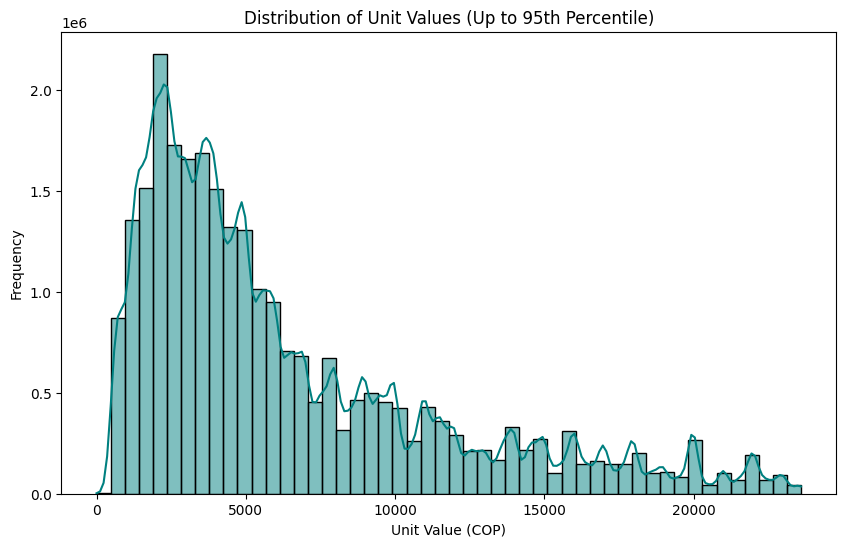

In [112]:
# Visualization 1: Distribution of Unit Values
# This helps identify the most common price points and potential outliers.
plt.figure(figsize=(10, 6))
sns.histplot(data_clean[data_clean['valor unitario'] < data_clean['valor unitario'].quantile(0.95)]['valor unitario'], bins=50, kde=True, color='teal')
plt.title('Distribution of Unit Values (Up to 95th Percentile)')
plt.xlabel('Unit Value (COP)')
plt.ylabel('Frequency')
plt.show()

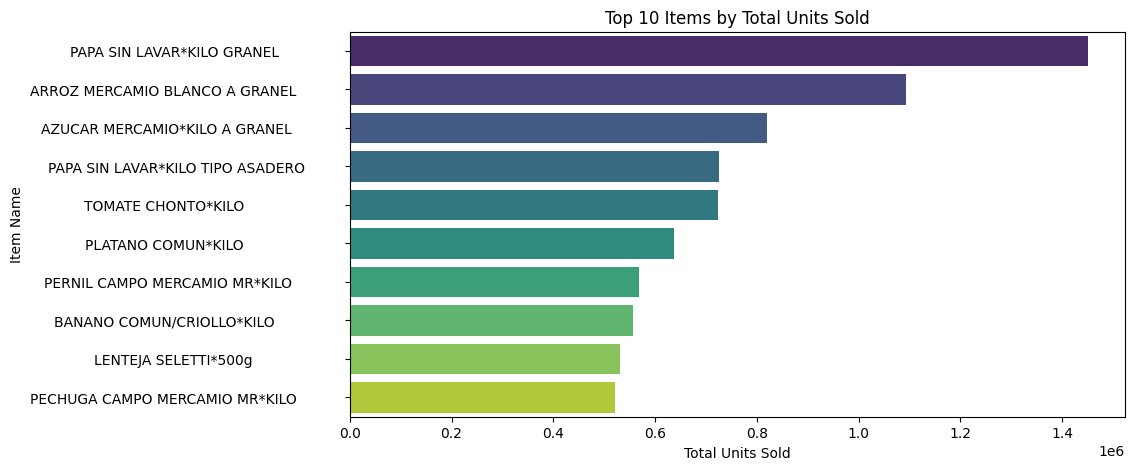

In [114]:
# Visualization 2: Top 10 Items by Total Units Sold
# This identifies the most popular products in the inventory.
top_items = data_clean.groupby('nombre_item')['unidades vendidas'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='viridis', legend=False)
plt.title('Top 10 Items by Total Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('Item Name')
plt.show()

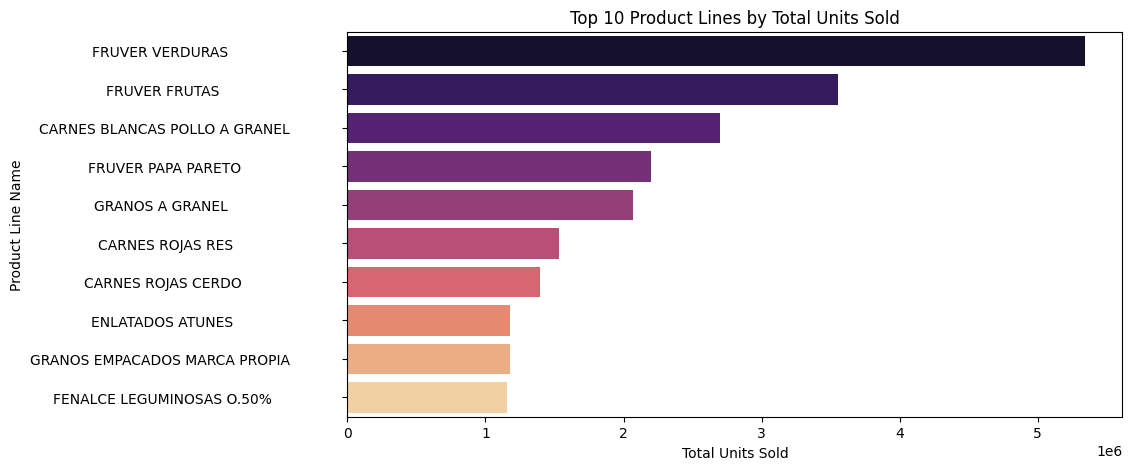

In [116]:
# Visualization 3: Top 10 lines by units sold
top_lines = data_clean.groupby('nombre_linea')['unidades vendidas'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_lines.values, y=top_lines.index, hue=top_lines
.index, palette='magma', legend=False)
plt.title('Top 10 Product Lines by Total Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Line Name')
plt.show()

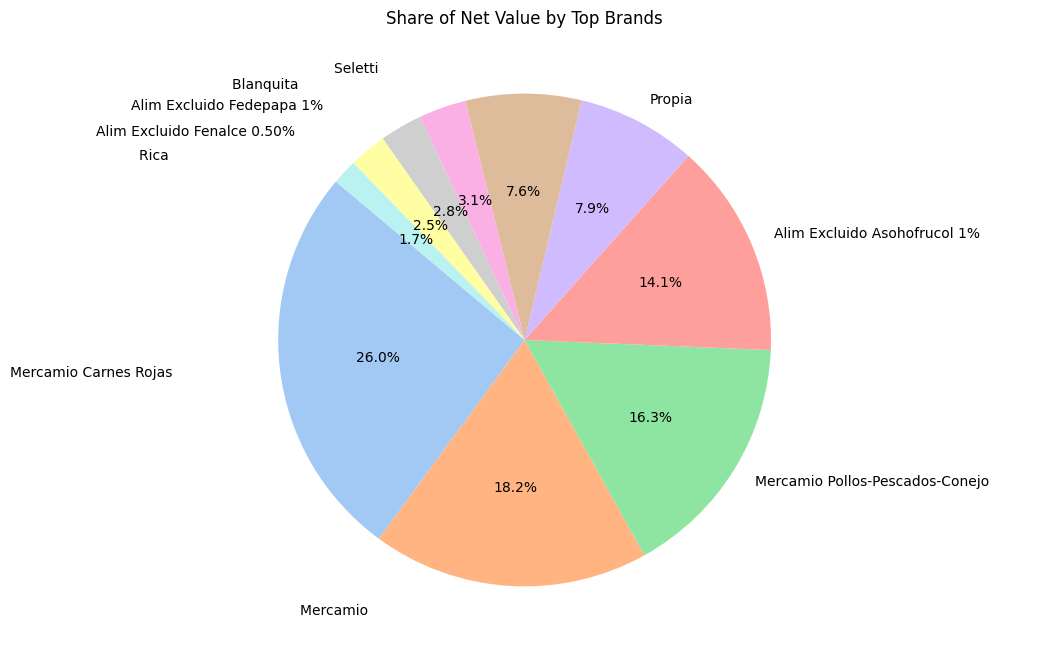

In [115]:
# Visualization 4: Net Value Sold by Brand (Marca)
# Comparing the performance of private labels ('Propia') vs other brands.
brand_performance = data_clean.groupby('marca')['valor_neto'].sum().sort_values(ascending=False).head(10)

# Adjust brand names to title case
brand_performance.index = brand_performance.index.str.title()

plt.figure(figsize=(8, 8))
brand_performance.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Share of Net Value by Top Brands')
plt.ylabel('') # Hiding the y-label for better aesthetics
plt.show()

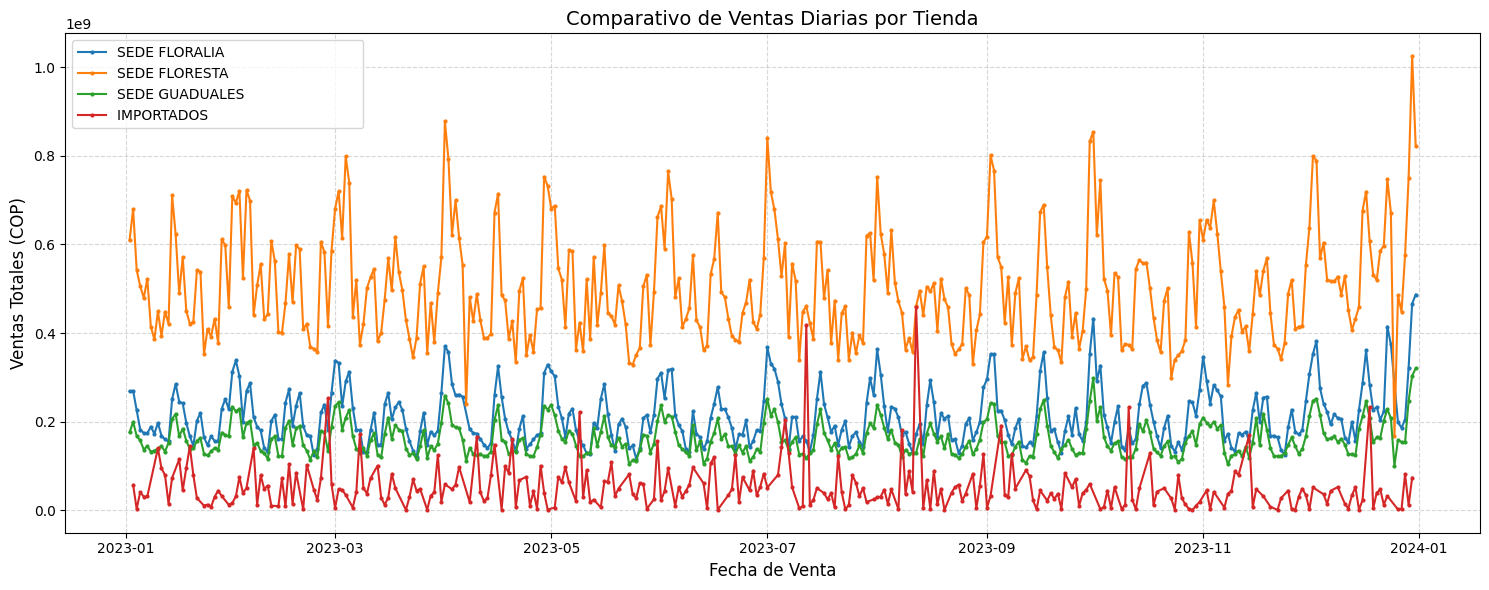

In [119]:
# Visualization 5: Daily Sales Trends by Store

# Group sales by day and store
ventas_diarias_tienda = data_clean.groupby(['fecha', 'nombre_centro_operacion'])['valor_neto'].sum().reset_index()

# Graphing
plt.figure(figsize=(15, 6))

# Plot a line for each store
for tienda in ventas_diarias_tienda['nombre_centro_operacion'].unique():
    tienda_data = ventas_diarias_tienda[ventas_diarias_tienda['nombre_centro_operacion'] == tienda]
    plt.plot(tienda_data['fecha'], tienda_data['valor_neto'], linewidth=1.5, label=tienda, marker='o', markersize=2)

# Add titles and labels
plt.title('Comparativo de Ventas Diarias por Tienda', fontsize=14)
plt.xlabel('Fecha de Venta', fontsize=12)
plt.ylabel('Ventas Totales (COP)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [123]:
# Visualization 6: Heatmap of Sales Intensity by Month and Day of the Week

# 1. Extracting month and day of the week from the 'fecha' column
data_clean['Mes_Num'] = data_clean['fecha'].dt.month
data_clean['Dia_Num'] = data_clean['fecha'].dt.dayofweek # 0=Lunes, 6=Domingo

# 2. Dicctionaries to map month and day numbers to Spanish names
meses_es = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio', 
            7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}
dias_es = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}

# 3. Creating a pivot table to prepare data for the heatmap
heatmap_data = data_clean.pivot_table(
    index='Mes_Num', 
    columns='Dia_Num', 
    values='valor_neto', 
    aggfunc='sum'
)

# 4. Renaming the index and columns to Spanish names for better readability in the heatmap
heatmap_data.index = heatmap_data.index.map(meses_es)
heatmap_data.columns = heatmap_data.columns.map(dias_es)

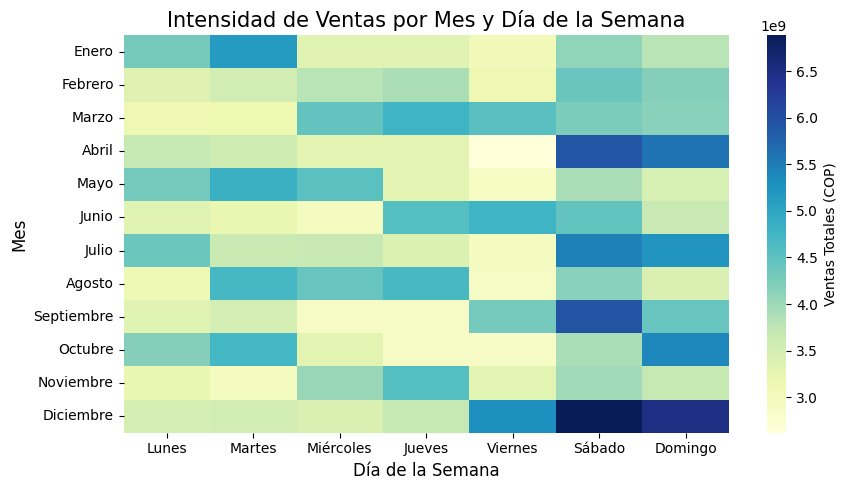

In [122]:
# 5. Graphing the heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt='.0f', cbar_kws={'label': 'Ventas Totales (COP)'})

plt.title('Intensidad de Ventas por Mes y Día de la Semana', fontsize=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Mes', fontsize=12)
plt.tight_layout()
plt.show()

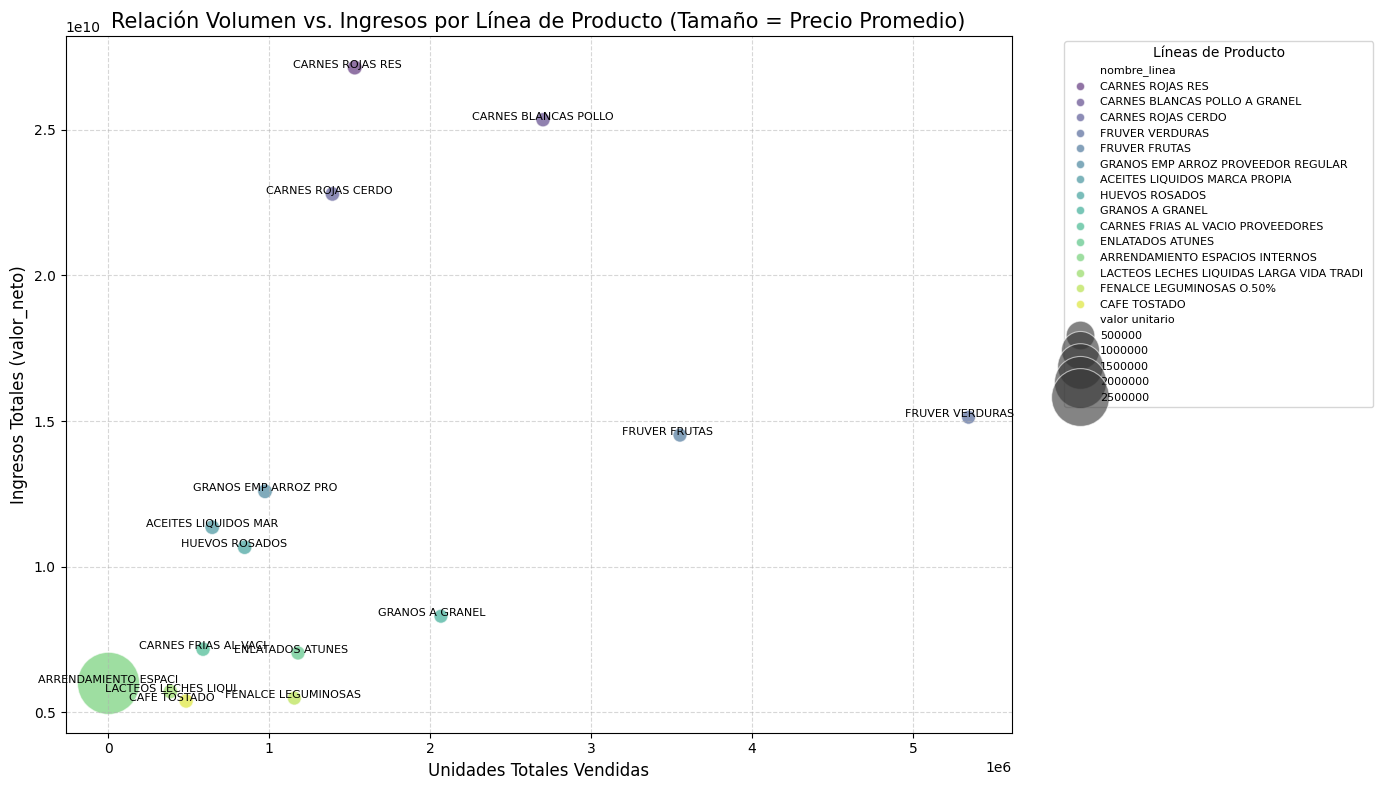

In [125]:
# Visualization 7: Bubble Chart of Volume vs. Net Value by Product Line

# 1. Grouping data by Product Line
# Calculate: Total sales, Total units, and Average unit price
line_stats = data_clean.groupby('nombre_linea').agg({
    'valor_neto': 'sum',
    'unidades vendidas': 'sum',
    'valor unitario': 'mean'
}).reset_index()

# 2. Filter the Top 15 product lines by net value for better readability
top_lines_bubble = line_stats.nlargest(15, 'valor_neto')

# 3. Create the bubble chart
plt.figure(figsize=(14, 8))

scatter = sns.scatterplot(
    data=top_lines_bubble, 
    x='unidades vendidas', 
    y='valor_neto', 
    size='valor unitario', 
    hue='nombre_linea', 
    sizes=(100, 2000), 
    alpha=0.6, 
    palette='viridis'
)

# 4. Add labels to each bubble
for i in range(top_lines_bubble.shape[0]):
    plt.text(
        x=top_lines_bubble['unidades vendidas'].iloc[i], 
        y=top_lines_bubble['valor_neto'].iloc[i], 
        s=top_lines_bubble['nombre_linea'].iloc[i][:20],  # Truncate for readability
        fontsize=8,
        ha='center'
    )

# Setting titles and labels
plt.title('Relación Volumen vs. Ingresos por Línea de Producto (Tamaño = Precio Promedio)', fontsize=15)
plt.xlabel('Unidades Totales Vendidas', fontsize=12)
plt.ylabel('Ingresos Totales (valor_neto)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Líneas de Producto', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


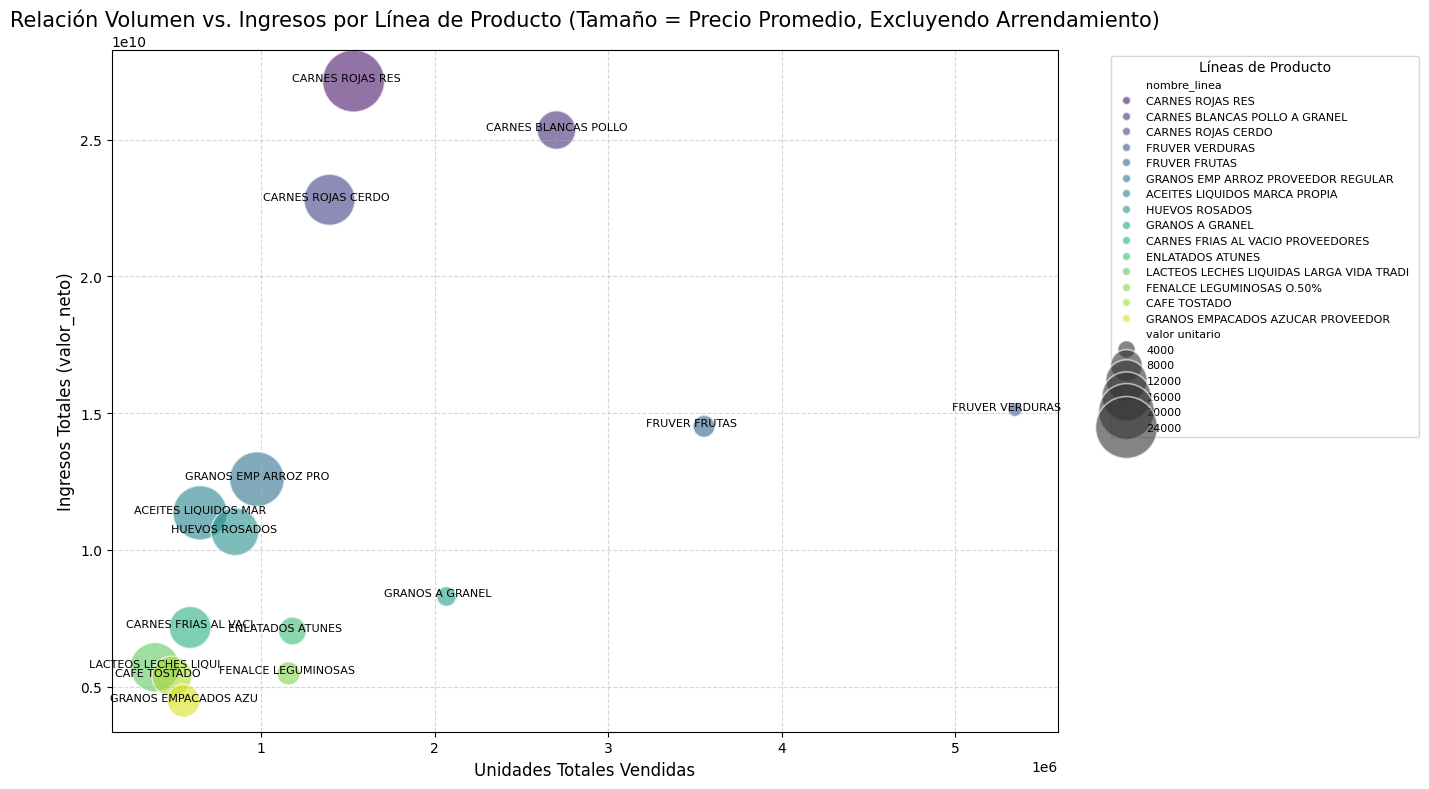

In [129]:
# Visualization 8: Bubble Chart of Volume vs. Net Value by Product Line (Excluding Leasing Spaces)

# 1. Grouping data by Product Line
# Calculate: Total sales, Total units, and Average unit price
line_stats = data_clean.groupby('nombre_linea').agg({
    'valor_neto': 'sum',
    'unidades vendidas': 'sum',
    'valor unitario': 'mean'
}).reset_index()

# Exclude 'ARRENDAMIENTO ESPACIOS INTERNOS' as it is an outlier with extremely high unit value
line_stats = line_stats[line_stats['nombre_linea'].str.strip() != 'ARRENDAMIENTO ESPACIOS INTERNOS']

# 2. Filter the Top 15 product lines by net value for better readability
top_lines_bubble = line_stats.nlargest(15, 'valor_neto')

# 3. Create the bubble chart
plt.figure(figsize=(14, 8))

scatter = sns.scatterplot(
    data=top_lines_bubble, 
    x='unidades vendidas', 
    y='valor_neto', 
    size='valor unitario', 
    hue='nombre_linea', 
    sizes=(100, 2000), 
    alpha=0.6, 
    palette='viridis'
)

# 4. Add labels to each bubble
for i in range(top_lines_bubble.shape[0]):
    plt.text(
        x=top_lines_bubble['unidades vendidas'].iloc[i], 
        y=top_lines_bubble['valor_neto'].iloc[i], 
        s=top_lines_bubble['nombre_linea'].iloc[i][:20],  # Truncate for readability
        fontsize=8,
        ha='center'
    )

# Setting titles and labels
plt.title('Relación Volumen vs. Ingresos por Línea de Producto (Tamaño = Precio Promedio, Excluyendo Arrendamiento)', fontsize=15)
plt.xlabel('Unidades Totales Vendidas', fontsize=12)
plt.ylabel('Ingresos Totales (valor_neto)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Líneas de Producto', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Conclusiones

A lo largo de este análisis exploratorio trabajamos con el dataset consolidado de ventas del año 2023, compuesto por cerca de **28 millones de transacciones** distribuidas en **4 sedes** (Floresta, Floralia, Guaduales e Importados), **361 líneas de producto** y **885 marcas**.

Durante la limpieza eliminamos los registros correspondientes a devoluciones y cobros del impuesto por bolsa plástica, que no representan ventas reales, e imputamos más de **1.2 millones de valores nulos** en la columna de marca. Con esto obtuvimos un dataset confiable y consistente como punto de partida para el modelado.

Al explorar el comportamiento de las ventas, identificamos que el desempeño está concentrado en un grupo reducido de líneas de producto de alto volumen, donde las marcas propias representan una participación significativa del valor neto total. Aplicando el análisis de outliers por IQR segmentado, encontramos que cerca del **41% de los registros** presentan algún tipo de anomalía en precio o volumen dentro de su propia categoría, lo cual es consistente con la alta variabilidad natural de un negocio de retail con múltiples líneas y rangos de precios muy distintos.

El análisis temporal nos permitió confirmar una estacionalidad clara: observamos picos cíclicos asociados a las quincenas y un aumento considerable en el volumen de transacciones hacia el mes de diciembre. Este comportamiento nos indica que la demanda es predecible y responde a ciclos económicos locales bien definidos, lo que sienta una base sólida para los modelos de series temporales que desarrollaremos en las siguientes etapas del proyecto.

Como siguiente paso, el dataset limpio almacenado en `data/processed/clean_data.csv` será la entrada principal para el proceso de construcción, entrenamiento y evaluación de los modelos de predicción de demanda.